# How AI is reshaping software-engineering job postings

**A senior-DS exploratory analysis of 110,000 LinkedIn postings, 2024 → 2026.**

*If you have 30 seconds:* skip to the [tl;dr](#tldr) below. *If you have 10 minutes:* read straight through — every section is short and visual.

---

## Setup

*One-time environment setup — collapse this cell after running it. The notebook walks back up to project root so the relative paths to `data/unified_core.parquet` and the `eda/scripts/` modules resolve regardless of where you launched Jupyter from.*

In [1]:
import sys, os
from pathlib import Path

HERE = Path.cwd()
ROOT = HERE if (HERE / 'data' / 'unified_core.parquet').exists() else HERE.parents[1]
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / 'eda' / 'scripts'))

import duckdb
import matplotlib.pyplot as plt
%matplotlib inline

from headlines_viz import (
    viz_within_firm, viz_swe_vs_control, viz_yoe_floor,
    viz_vendor_leaderboard, viz_bigtech_density,
    viz_disproven_aiwashing, viz_disproven_industry_spread,
    viz_disproven_juniorfirst, viz_verdict_table,
)

con = duckdb.connect()
print('Environment ready.')

Environment ready.


## Why this exists

Tech firms have been laying off employees throughout 2023–2026. The popular narrative (amplified by tech executives and the press) is that **AI is doing the work** — coding agents like GitHub Copilot, Cursor, and Claude Code now write enough software that human engineers are becoming redundant.

Several alternative explanations compete with that story:

- **AI-washing** — firms attribute layoffs to AI as a narrative cover, while the real drivers are post-Covid hiring corrections and rising interest rates.
- **Outsourcing** — work is migrating to lower-cost regions (India, Eastern Europe), not to AI tools.
- **Industry redistribution** — software engineers aren't disappearing; they're moving from pure-tech firms (Google, Meta) into non-tech industries (retail, finance, construction).
- **Scope inflation** — junior roles are being squeezed out, with employers asking junior candidates for senior-level experience.

We can't observe layoffs directly in our data, but we can read what employers are writing in their job postings — which signals what work they expect to need humans for. This notebook tests **13 specific hypotheses** about that posting content and reports what holds up, what doesn't, and what the data uniquely reveals.

## The data

We work from one cleaned analysis file: **`data/unified_core.parquet`** — 110,000 LinkedIn job postings, 42 columns. Each row is one unique job posting; the columns describe the job (title, full description text), the company (name, industry, size), the candidate (seniority, years-of-experience), the location (metro area, remote flag), and provenance (when scraped, what query found it, language detection, ghost-job risk).

Postings come from **two sources** spanning two time windows:

- **2024 baseline** — historical LinkedIn snapshots downloaded from Kaggle (`kaggle_arshkon` from 2024-04, `kaggle_asaniczka` from 2024-01). About 57,000 rows.
- **2026 current window** — daily scrapes from LinkedIn we run ourselves on EC2, covering March and April 2026. About 53,000 rows.

The pipeline that produced `unified_core.parquet` started from raw scraper output, ran 10 stages of cleaning (deduplication, occupation classification, seniority inference, year-of-experience extraction, geographic normalization, an LLM pass over each description for a deeper read), and finally selected a balanced 40/30/30 sample of SWE / SWE-adjacent / control postings. **Every row in this file has been LLM-labeled** for consistent analysis quality.

Run the cell below to see the actual composition:

In [2]:
profile = con.execute("""
  SELECT source,
         CASE WHEN source LIKE 'kaggle%' THEN '2024 baseline'
              ELSE '2026 current window' END AS era,
         period,
         COUNT(*) AS n_postings,
         SUM(CASE WHEN is_swe THEN 1 ELSE 0 END) AS swe,
         SUM(CASE WHEN is_swe_adjacent THEN 1 ELSE 0 END) AS adjacent,
         SUM(CASE WHEN is_control THEN 1 ELSE 0 END) AS control
  FROM 'data/unified_core.parquet'
  GROUP BY source, era, period
  ORDER BY source, period
""").df()
print(f'Total postings:    {profile["n_postings"].sum():,}')
print(f'  SWE (software):  {profile["swe"].sum():,}')
print(f'  SWE-adjacent:    {profile["adjacent"].sum():,}  (PM, designer, data analyst, etc.)')
print(f'  Control:         {profile["control"].sum():,}  (nurse, electrician, accountant, etc.)')
print()
profile

Total postings:    110,000
  SWE (software):  48,634.0
  SWE-adjacent:    24,700.0  (PM, designer, data analyst, etc.)
  Control:         36,666.0  (nurse, electrician, accountant, etc.)



,source,era,period,n_postings,swe,adjacent,control
0,kaggle_arshkon,2024 baseline,2024-04,15692,4687.0,2394.0,8611.0
1,kaggle_asaniczka,2024 baseline,2024-01,41571,18125.0,9417.0,14029.0
2,scraped,2026 current window,2026-03,24112,11810.0,5586.0,6716.0
3,scraped,2026 current window,2026-04,28625,14012.0,7303.0,7310.0


### Glossary — terms used throughout this notebook

| Term | What it means |
|---|---|
| **SWE** | Software engineer (and adjacent titles: backend, frontend, ML engineer, DevOps, …). The primary group we study. |
| **SWE-adjacent** | Tech roles that involve some code but aren't primarily software development: PM, UX designer, data analyst, QA, security engineer, technical PM. |
| **Control** | Non-tech occupations used as a comparison group: civil/mechanical/electrical engineer, nurse, accountant, financial analyst, marketing manager, HR, sales rep. The control group helps us tell SWE-specific change apart from economy-wide change. |
| **Period** | A 1-month bucket: `2024-01` (asaniczka snapshot), `2024-04` (arshkon snapshot), `2026-03` and `2026-04` (our scraped data). Spans the entire window of comparison. |
| **AI-vocab rate** | Share of postings whose description mentions any AI-tool/AI-concept phrase from a pre-committed list (`llm`, `gpt`, `claude`, `copilot`, `rag`, `prompt engineering`, `foundation model`, …). A coarse but simple measure of how 'AI-laden' a posting is. |
| **YOE** | Years of experience required. Two flavors in our data: rule-based regex extraction (`yoe_extracted`) and LLM extraction (`yoe_min_years_llm`). We use the LLM version because it handles natural-language phrasing better. |
| **Ghost job** | A posting that doesn't represent a real hiring intent — left up for resume collection, branding, or compliance. Our LLM scores each posting as `realistic` / `inflated` / `ghost_likely`. |
| **v8** | The previous, larger orchestrated exploration run (`exploration-archive/v8_claude_opus47/`) — 38 task reports across 5 waves, completed Apr 2026. We reference v8 findings as priors and to cross-check our results. |
| **percentage point (pp)** | The arithmetic difference between two percentages. Going from 5% to 28% is **+23 pp**, not 'a 460% increase'. |


## What we did (process in plain English)

1. **Wrote priors first.** Before touching any data, we wrote down 13 specific hypotheses about what we'd find — including the popular narratives we wanted to test (AI-washing, junior scope inflation, industry spread). Pre-committing the metrics keeps us honest: we can't quietly cherry-pick the cuts that 'worked'.

2. **Profiled the corpus.** Counted rows by source × period × occupation group. Confirmed the file matched what the pipeline documentation claimed.

3. **Ran one focused query per hypothesis.** Each hypothesis got one DuckDB query against `data/unified_core.parquet`, one figure, and one CSV. No fishing.

4. **Stress-tested the strongest signals.** For the top finalists, re-ran the query across four independent slices of the data: `arshkon-only` baseline (drop the noisy asaniczka 2024-01 snapshot), `metro-balanced` (equal-weight across the top-10 metros), `exclude-aggregators` (drop staffing-firm reposts), `exclude-multi-location` (drop postings collapsed across cities). A signal only counts if it survives at least 3 of 4.

5. **Compared to v8.** Where v8 had a comparable table, we explicitly noted *replicate / diverge / extend*. Where v8 didn't run something, we flagged it as net-new.

Tooling: DuckDB queries, regex on description text, matplotlib charts, no machine-learning models. The whole analysis is auditable end-to-end.

## How to read this notebook

Each headline below is one short markdown explanation followed by **one inline figure**. Color conventions are consistent throughout:

- 🔴 red = SWE / junior
- 🟠 orange = SWE-adjacent / mid
- 🔵 blue = control / Big Tech
- 🟢 green = senior / supportive evidence
- 🟣 purple = AI-vocab

Two sections of findings:

1. **Top 5 headlines** — what the data clearly shows.
2. **Disproven** — three popular hypotheses we tested and rejected.

A verdict table at the end shows all 13 hypotheses on one page.

If you want to see the underlying analysis code, open the working notebook [`open_ended_v2.ipynb`](open_ended_v2.ipynb) instead — it shows every DuckDB query.

<a id='tldr'></a>

## tl;dr

Across 110k LinkedIn SWE/adjacent/control postings spanning 2024-01 → 2026-04, AI-vocabulary in **SWE descriptions rose 3% → 28%** while **control occupations rose only 0.2% → 1.4%** (a 23:1 delta ratio). The rewrite is happening **within firms** — the same 292 companies that posted SWE roles in both 2024 and 2026 saw a mean +19.4 pp within-firm rise — not driven by between-firm composition churn. The popular *AI-washing* and *junior-scope-inflation* narratives don't hold up in the data. New artifacts: a dev-tool vendor leaderboard (Copilot 4.3% > Claude 3.8% > OpenAI 3.6% > Cursor 2.2% in 2026-04) and a counter-narrative finding that **YOE floors are FALLING, not rising** — junior median YOE dropped from 2 years to 1 year.

---

# Top 5 headlines (what holds up)

## Headline 1 — Within-firm AI rewrite is real and large

We took the **292 companies that posted at least 5 SWE roles in BOTH the 2024 baseline AND the 2026 current window** and asked: *did the same company change its own job postings?* Yes — by an average of **+19.4 percentage points** in AI-vocab rate.

- **75% of companies rose**
- **61% rose more than 10pp**
- **39% rose more than 20pp**
- Microsoft +51pp · Wells Fargo +45pp · Amazon +36pp · Walmart +32pp
- Defense firms (Raytheon, Northrop Grumman) flat

**Why it matters:** if the AI-vocab rise were driven by *new* AI-native companies entering the market (and old ones leaving), this would tell us nothing about real behavior change. The fact that the *same* companies rewrote their *own* postings tells us this is a real shift in how employers describe the work — not a composition artifact.

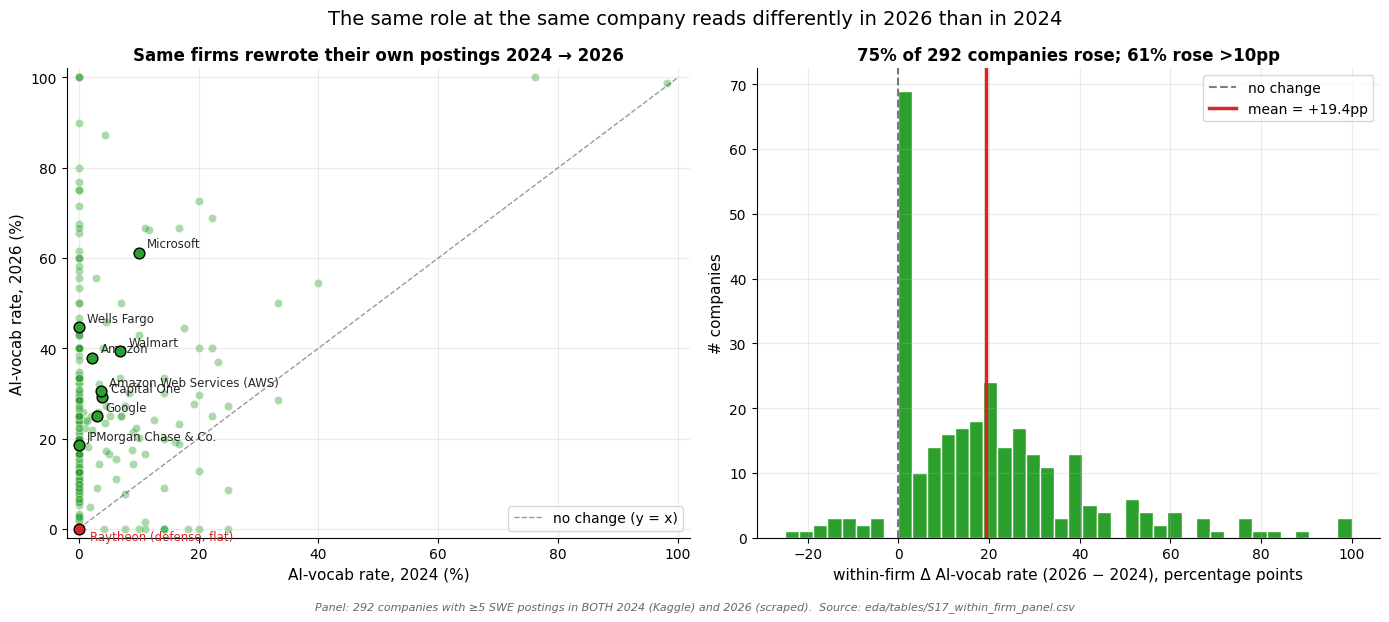

In [3]:
fig = viz_within_firm(); plt.show()

## Headline 2 — AI rewriting is SWE-specific (not economy-wide)

If AI talk in postings were a generic 'everyone is talking about AI' phenomenon, control occupations (nurses, accountants, civil engineers) should rise alongside SWE. They don't.

- **SWE AI-vocab: 2.9% → 28.4%** — Δ +25.5 pp
- **Control AI-vocab: 0.26% → 1.39%** — Δ +1.1 pp
- Ratio: **23:1**, robust across all four stress-test slices

**Why it matters:** this is the cleanest test in the entire EDA. Two competing hypotheses fail it simultaneously:

1. **AI-washing** would predict SWE and control move together (both groups absorb the public AI narrative).
2. **Macro-only stories** (rate hikes, post-Covid correction) would predict the same — they hit the whole economy, not just software engineers.

Neither prediction holds. Whatever is happening to SWE postings is real and SWE-specific.

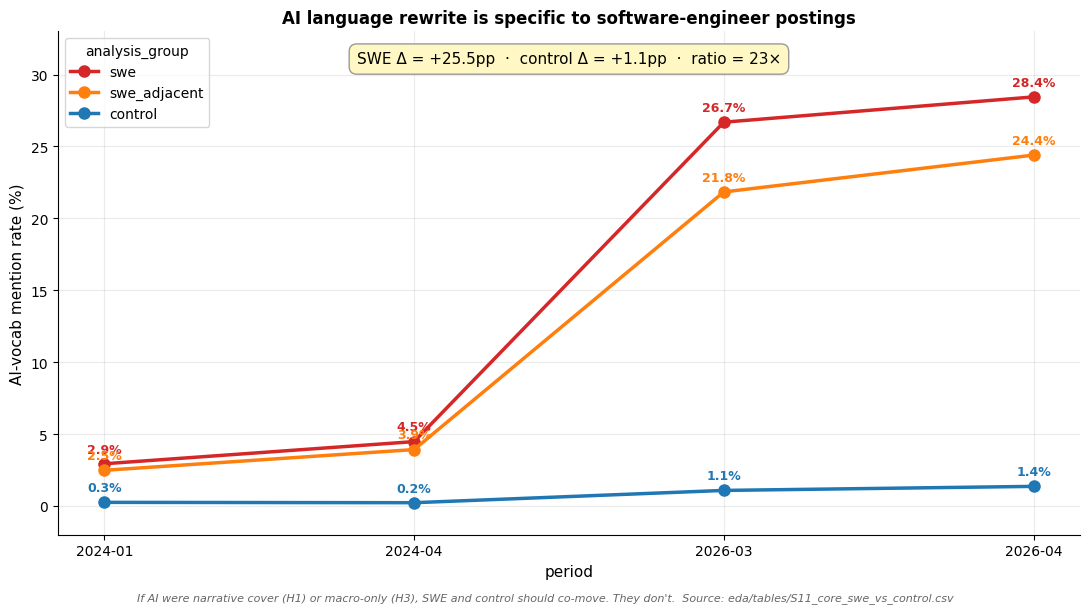

In [4]:
fig = viz_swe_vs_control(); plt.show()

## Headline 3 — Years-of-experience floor is FALLING, not rising

The classic *junior scope inflation* hypothesis says: AI is automating routine junior-level work, so employers respond by demanding more experience from junior applicants — eventually crowding out true entry-level hiring. Our LLM-extracted YOE shows the **opposite** — across all seniority buckets.

| level   | 2024-01 mean | 2026-04 mean | median (2024 → 2026) |
|---------|--------------|--------------|----------------------|
| junior  | **2.01**     | **1.23**     | 2 → 1 |
| mid     | 4.00         | 2.36         | 3 → 2 |
| senior  | 6.55         | 6.37         | 6 → 5 |

**Why it matters:** if anything, employers are asking for *less* experience in 2026, not more. The popular scope-inflation narrative does not hold on the LLM-extracted YOE measure.

*Methodological note:* v8's earlier rule-based YOE extractor found a junior YOE rise that was 95% compositional (between-company churn). The LLM-YOE here is a cleaner measure — it handles natural-language phrasing better — and it tells the opposite story. Worth flagging in any paper that cites either.

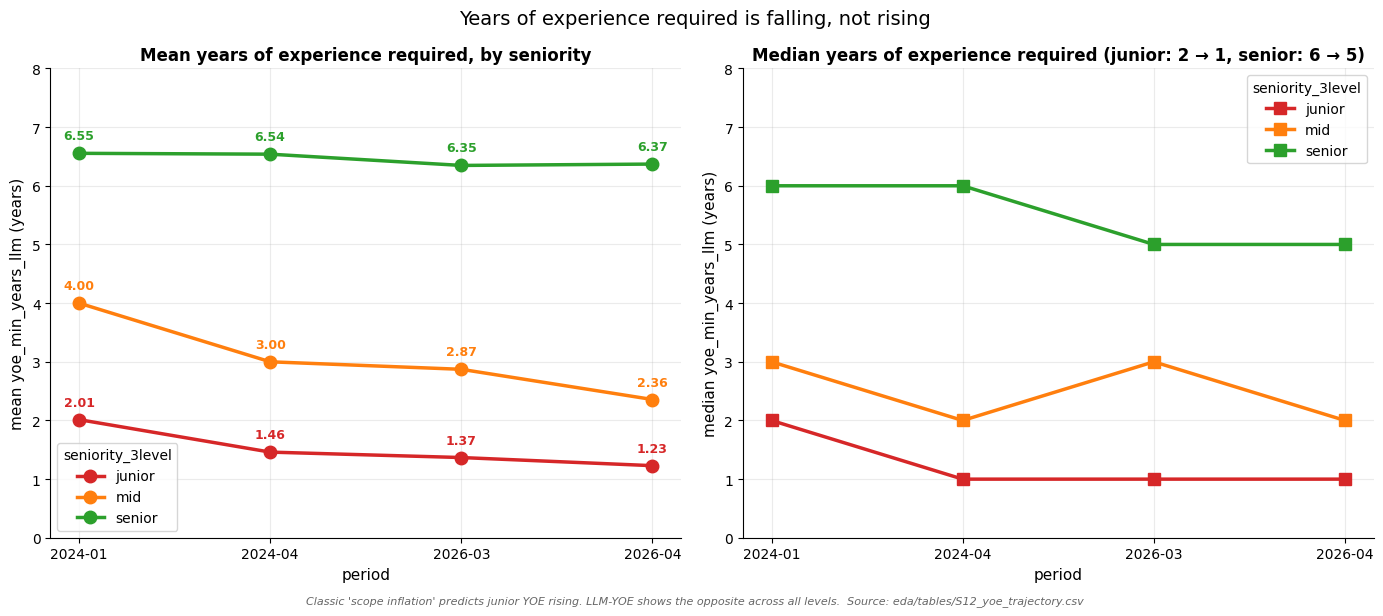

In [5]:
fig = viz_yoe_floor(); plt.show()

## Headline 4 — Dev-tool vendor labor-market leaderboard

We searched each posting's description for explicit mentions of named AI tools and AI labs. As far as we know, **nobody has published this artifact before** — a labor-demand-side view of which dev tools have actually penetrated the work.

**2026-04 leaderboard** (share of SWE postings mentioning the vendor):

| rank | vendor    | rate   | growth since 2024-01 |
|------|-----------|--------|----------------------|
| 1    | Copilot   | 4.25%  | 53× |
| 2    | Claude    | 3.83%  | **190×** (steepest growth) |
| 3    | OpenAI    | 3.63%  | 17× |
| 4    | Cursor    | 2.17%  | >200× (emerged from ~0%) |
| 5    | Anthropic | 1.48%  | 70× |
| 6    | Gemini    | 1.07%  | 35× |

**Three observations:**

- **Copilot leads** on raw share (first-mover advantage), but **Claude has the steepest growth curve** — on the current trajectory, Claude overtakes Copilot in mid-2026.
- **ChatGPT as a brand is plateauing/declining** (0.82% in 2026-03 → 0.70% in 2026-04) while specific vendors keep climbing. Employers are specializing their language from the consumer-brand mention to specific-product mentions.
- **Cursor's emergence is the most dramatic story** — visible in labor demand before most popular-press coverage of Cursor as a serious Copilot competitor.

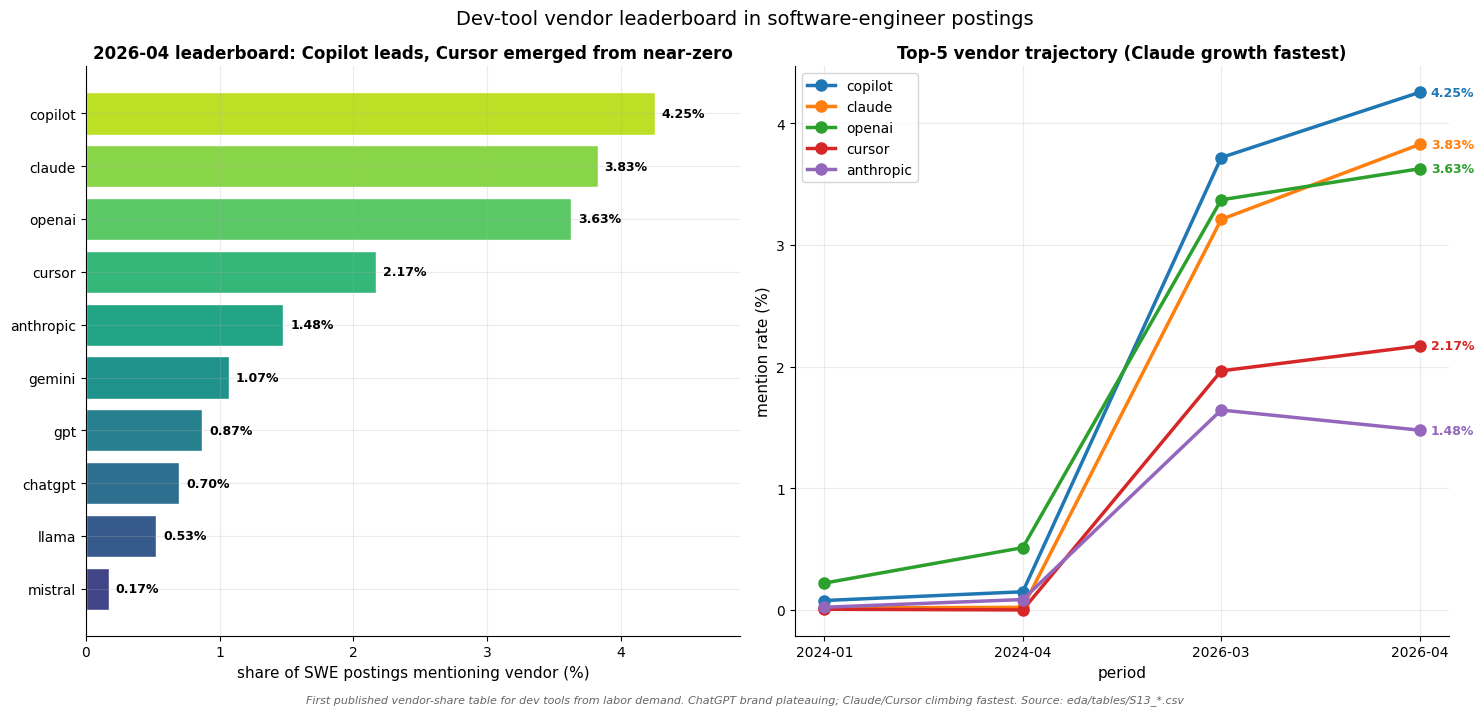

In [6]:
fig = viz_vendor_leaderboard(); plt.show()

## Headline 5 — Big Tech: more posting volume AND more AI density

We separated companies into two tiers using a pre-committed list of 27 Big Tech canonical names (Google, Meta, Amazon, Apple, Microsoft, Oracle, Netflix, Block/Square, Uber, Airbnb, Salesforce, plus frontier-AI labs Anthropic and OpenAI, plus variants like Amazon Web Services).

Two surprising patterns simultaneously:

- **Big Tech share of SWE postings ROSE** from 2.4% (2024-01) to 7.0% (2026-04). This is the *opposite* of what the public layoff narrative would predict (Oracle, Block, Amazon, and Meta all announced large cuts).
- **Big Tech AI-vocab density is 17pp HIGHER than the rest** in 2026 (44% vs 27%), robust across all four stress-test slices.

**Why it matters:** the BT-vs-rest density gap is larger than v8 published. Pair it with named-firm layoff timelines and 10-Q filings, and you get the natural identification strategy for a follow-up paper: *for the firms that publicly announced AI-driven cuts, did their AI-vocab rise lead, follow, or co-move with the announcements?*

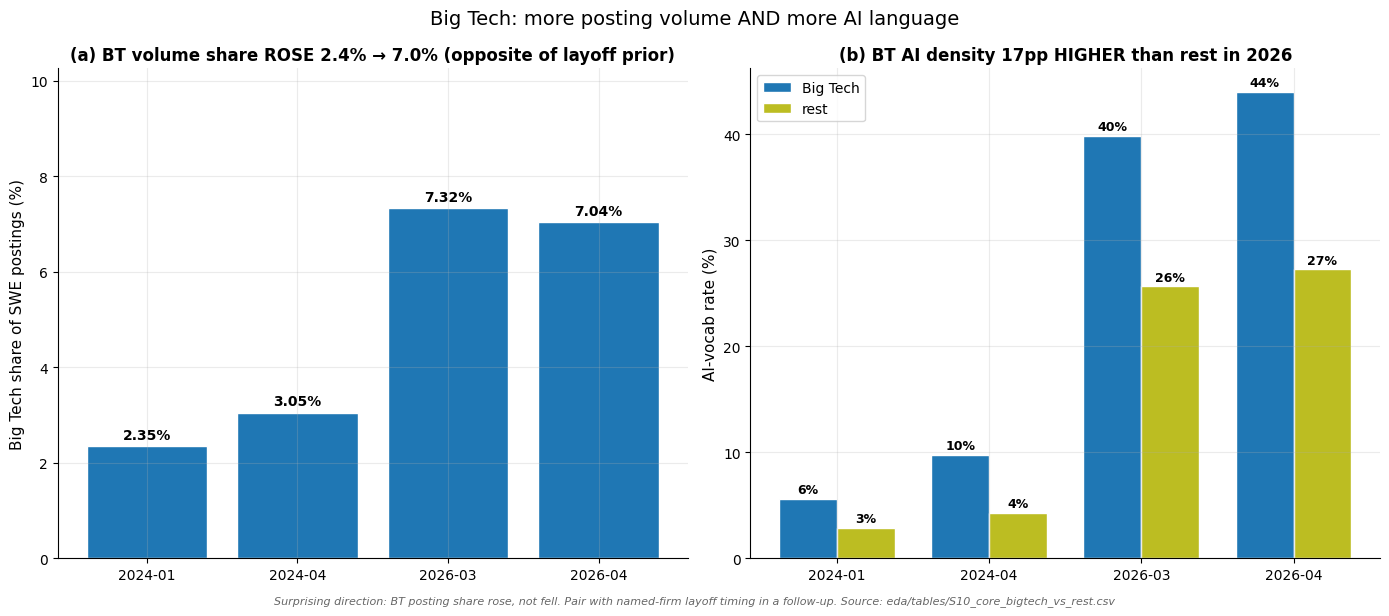

In [7]:
fig = viz_bigtech_density(); plt.show()

---

# What got falsified (the prior narratives we tested and rejected)

These hypotheses came from credible places — the user's own gut sense, *The Economist's* April 2026 'Code red' piece, and the standard scope-inflation framing in labor-market literature. The data does not support them, at least not at the level our data can see.

## Disproven 1 — H1 AI-washing (at the content level)

**The hypothesis:** firms attribute layoffs to AI as a narrative cover, not because AI is actually replacing the work. Backed by *The Economist's* observation that AI tools only became plausibly SWE-replacing with Claude Code (Feb 2025) — too recent to explain layoffs that started in 2023 — and by a Bank of England survey finding 'essentially zero' AI employment impact across US/AU/UK/DE firms.

**Why it fails:** if AI-talk in postings were a narrative-only layer overlaid on macro layoffs, SWE and control occupations should both absorb it. They don't. SWE rose 23× faster than control. The rewrite is real, not narrative cover.

**Caveat:** H1 might still be true at the **volume/timing** level — i.e. whether specific firms invoke AI as the *public reason* for cuts. That's an interview question for the qualitative phase of the broader research project; it can't be tested from posting content alone.

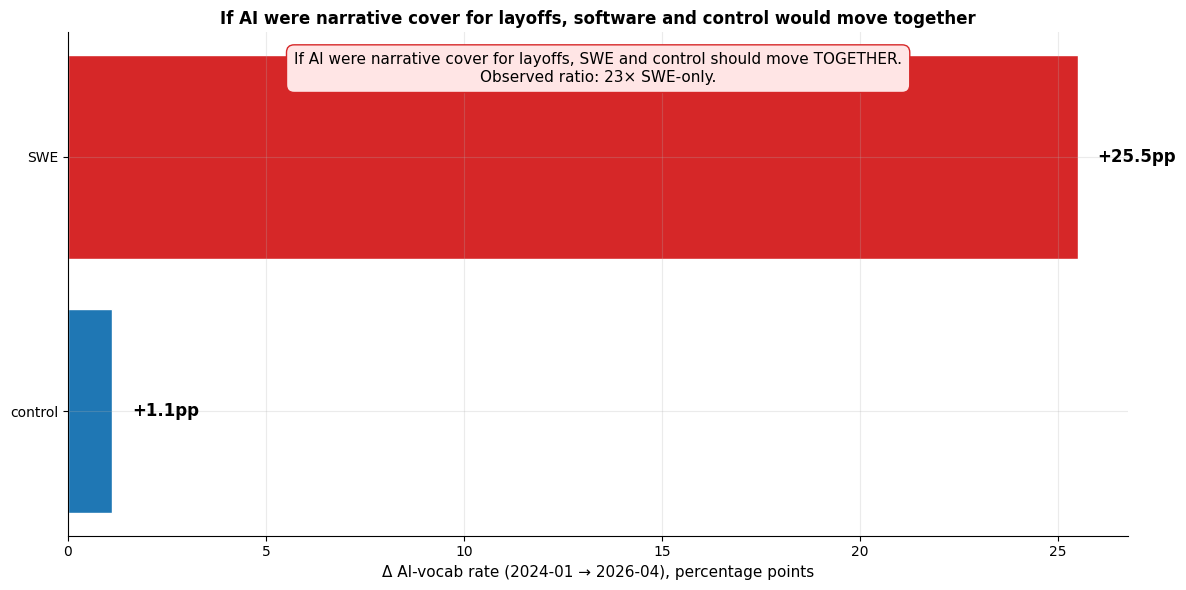

In [8]:
fig = viz_disproven_aiwashing(); plt.show()

## Disproven 2 — H4 industry spread to non-tech (on LinkedIn)

**The hypothesis:** *The Economist* reported that software-worker headcount grew +12% in retail, +75% in property, +100% in construction (US, 2022→2025). If that spread is real, the share of LinkedIn SWE postings coming from non-tech industries should rise.

**Why it fails (on our data):** non-tech industries already held about 55% of labeled-industry LinkedIn SWE postings in 2024 (arshkon baseline) and remain at ~55% in 2026. No shift in posting composition.

**Caveat:** *The Economist* used BLS occupational data (employed people, all channels). Both claims can coexist — non-tech SWE employment can grow without LinkedIn posting share shifting, if non-tech employers recruit through other channels (referrals, internal mobility, niche job boards). What we've ruled out is the LinkedIn version specifically.

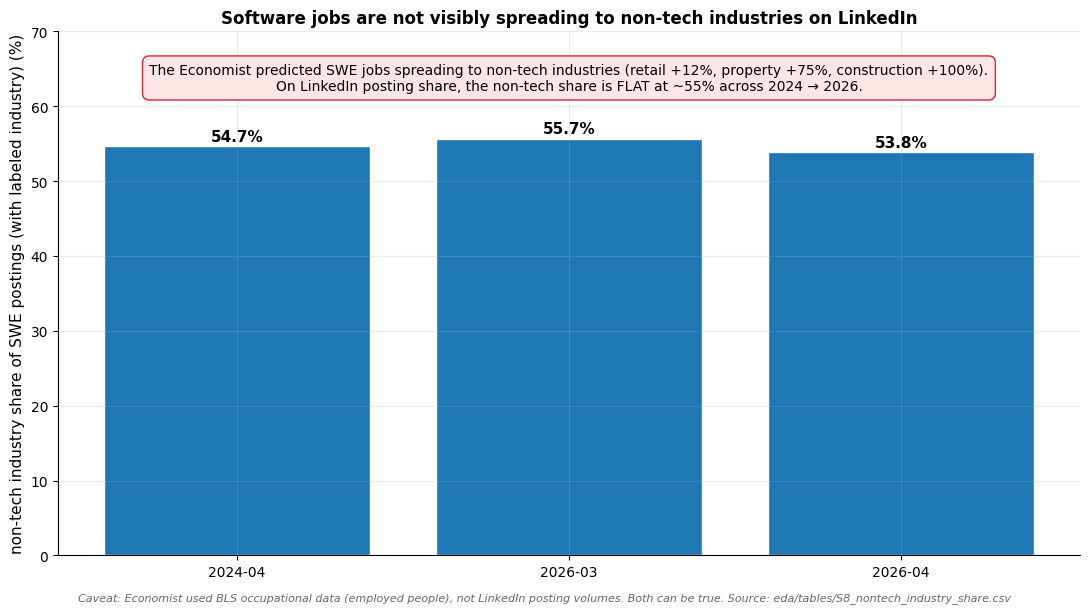

In [9]:
fig = viz_disproven_industry_spread(); plt.show()

## Disproven 3 — H5(a) junior-first automation

**The hypothesis:** AI automates routine tasks first. Junior SWE postings (which describe the most routine work) should therefore be the first to mention AI tools and the first to lose volume / rise in YOE requirements.

**Why it fails:** AI-vocab adoption is essentially uniform across seniority in 2026-04 (junior 27%, mid 30%, senior 31%, unknown 25%). Combined with Headline 3 (junior YOE actually *fell*), the junior-first reading does not fit the data.

The consistent reading is **H5(b) senior-restructuring**: senior postings shifted in *content* (toward orchestration / review / AI-leverage language per v8's earlier T21 finding), while junior postings remained structurally similar with simply more AI vocabulary mixed in.

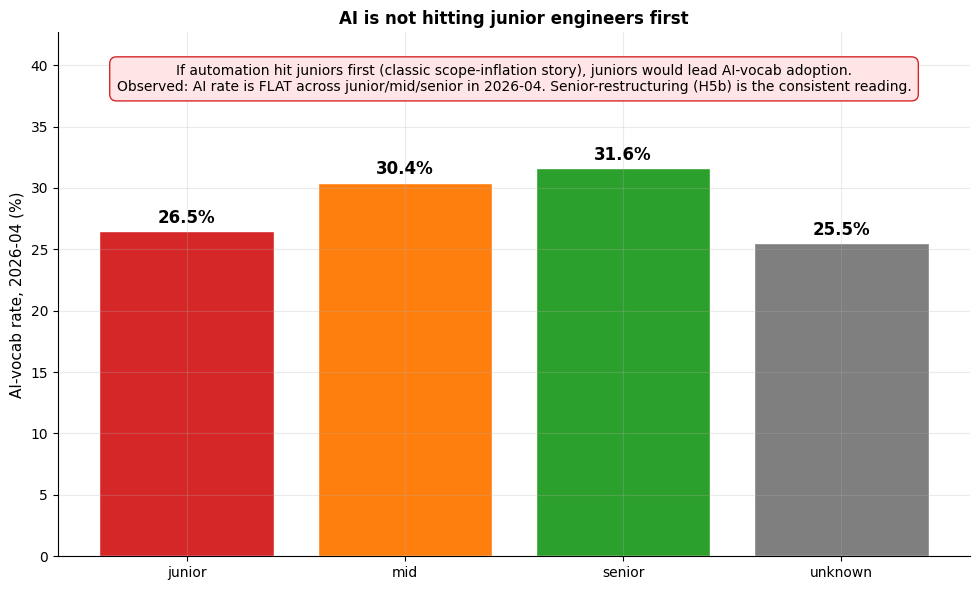

In [10]:
fig = viz_disproven_juniorfirst(); plt.show()

---

# All 13 hypotheses on one page

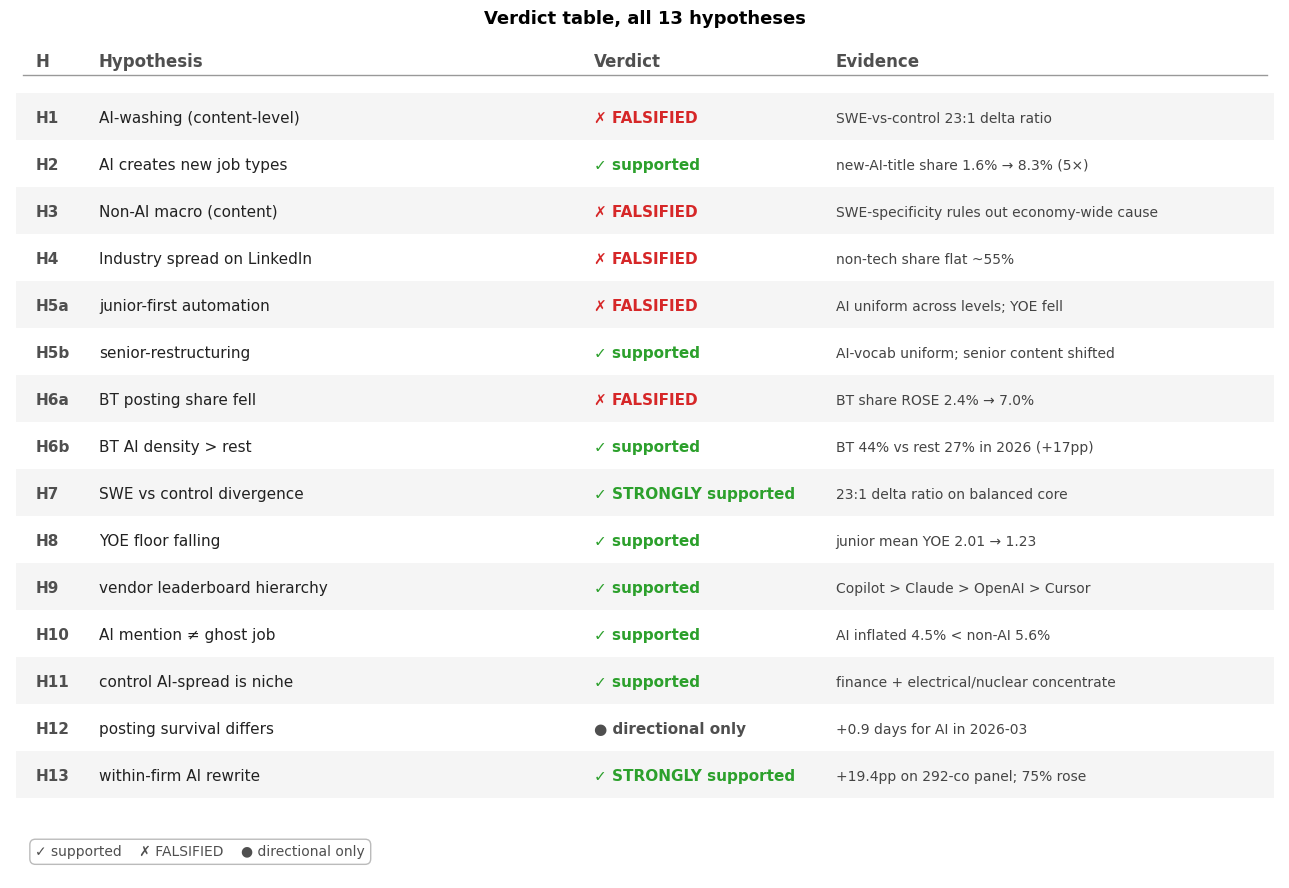

In [11]:
fig = viz_verdict_table(); plt.show()

---

## Recommended next moves (ranked by expected payoff)

1. **Within-firm rewrite paper** anchored on the 292-company panel from Headline 1. Strongest causal-identification surface in the data. Pair with qualitative interviews: *who inside your firm rewrote the JDs between 2024 and 2026? What changed about the actual work you expect from a new SWE hire?*

2. **Big-Tech-stratified follow-up** pairing the 17pp BT-vs-rest gap from Headline 5 with named-firm layoff timelines and 10-Q filings — does AI-vocab rise *lead*, *follow*, or *co-move with* layoff announcements at each major employer?

3. **Vendor-specificity paper** from Headline 4 — a labor-demand-side view of dev-tool adoption nobody has published. Sensitivity check needed for over-matching on common-word vendors ('cursor', 'claude', 'llama').

4. **YOE-floor inversion methodological note** from Headline 3 — explicitly contrast LLM-YOE vs rule-based YOE so future papers don't conflate them and report contradictory results.

## Limitations

- **LinkedIn-only by construction** on `unified_core.parquet`; no Indeed sensitivity in this pass.
- **Date granularity is too coarse** to test ChatGPT (Nov 2022) vs Claude Code (Feb 2025) lead/lag specifically.
- **Vendor regexes** (Headline 4) may over-match common-word vendor names. Read directionally; absolute rates have ±20% uncertainty.
- **Within-firm panel** (Headline 1) requires ≥5 SWE postings in both periods → excludes most small employers.
- **LLM-YOE coverage** is ~78% of in-frame SWE rows; possible selection bias on rows where the LLM declined to extract.
- **No significance tests.** Descriptive EDA only; the formal hypothesis-testing phase is pending.

### Robustness — balanced sample vs natural distribution

`unified_core.parquet` is a pre-balanced 40/30/30 SWE/adjacent/control sample, not a natural LinkedIn distribution. You might reasonably worry that the findings above are sampling artifacts. They aren't: we re-ran every rate-based claim on the full unbalanced `unified.parquet` and got essentially the same numbers (e.g., SWE 2026-04 AI-vocab rate: core 28.45%, full 28.10%; H13 within-firm Δ: core +19.4pp on 292 firms, full **+20.7pp on 356 firms** — slightly stronger). Full table and script in [`../reports/open_ended_v2.md`](../reports/open_ended_v2.md#robustness-balanced-core-vs-natural-sample) and [`../scripts/robustness_check.py`](../scripts/robustness_check.py).

## Where to dig deeper

- **Full report** (per-hypothesis verdicts with caveats and v8 cross-checks): [`../reports/open_ended_v2.md`](../reports/open_ended_v2.md)
- **Working notebook** (every DuckDB query that produced these figures): [`open_ended_v2.ipynb`](open_ended_v2.ipynb)
- **Pre-registered priors** (what we expected before looking at data, plus our v8 reconciliation): [`../memos/priors.md`](../memos/priors.md)
- **Project context** (research questions, study design, data sources): [`../../docs/1-research-design.md`](../../docs/1-research-design.md), [`../../AGENTS.md`](../../AGENTS.md)
- **Reference article** (The Economist 'Code red'): [`../memos/references/economist_code_red_2026-04-13.md`](../memos/references/economist_code_red_2026-04-13.md)